In [2]:
import pandas as pd
df = pd.read_csv("../data/processed/clean.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/clean.csv'

In [3]:
import pandas as pd
df = pd.read_csv(r"C:\Users\pradh\OneDrive\Desktop\Customer Churn Prediction and Retention Analysis\churn-project\data\processed\clean.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Shape:", df.shape)
print("\nChurn distribution:")
print(df["Churn"].value_counts(normalize=True))

Shape: (7043, 20)

Churn distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


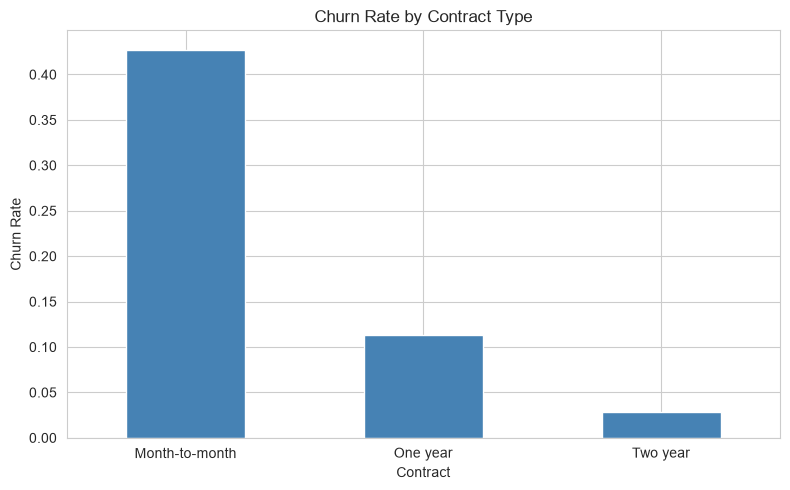

In [5]:
contract_churn = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
print(contract_churn)

contract_churn.plot(kind="bar", color="steelblue")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

tenure_bucket
0-12mo     0.476782
13-24mo    0.287109
25-48mo    0.203890
49-72mo    0.095132
Name: Churn, dtype: float64


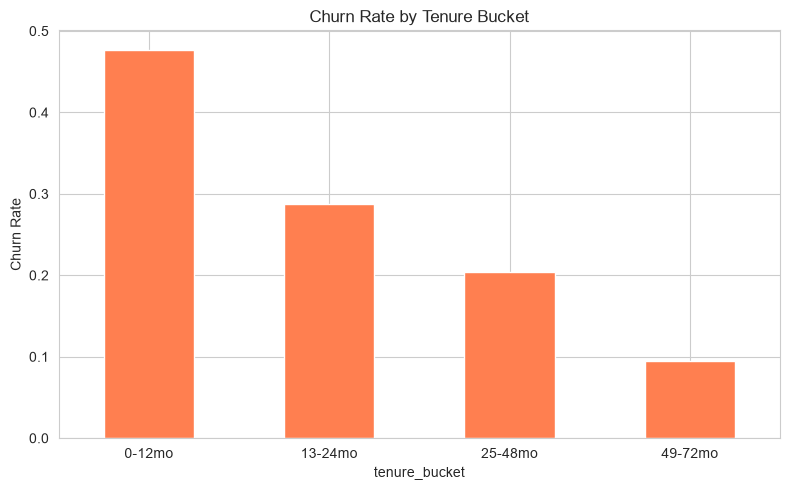

In [6]:
df["tenure_bucket"] = pd.cut(df["tenure"], bins=[0, 12, 24, 48, 72],
                               labels=["0-12mo", "13-24mo", "25-48mo", "49-72mo"])

tenure_churn = df.groupby("tenure_bucket", observed=True)["Churn"].mean()
print(tenure_churn)

tenure_churn.plot(kind="bar", color="coral")
plt.title("Churn Rate by Tenure Bucket")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

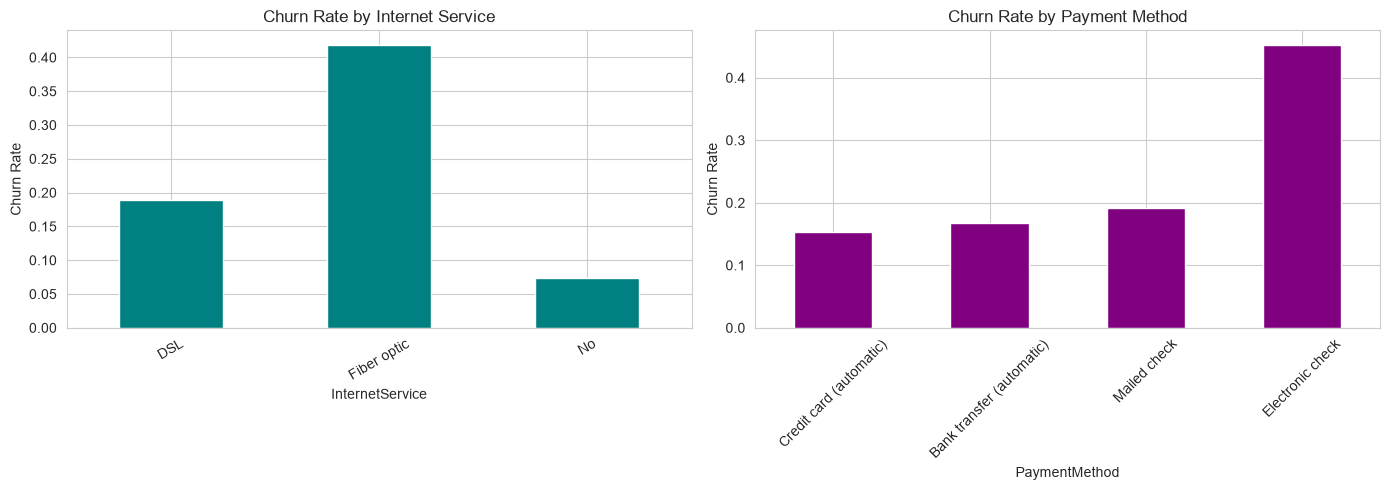

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby("InternetService")["Churn"].mean().plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Churn Rate by Internet Service")
axes[0].set_ylabel("Churn Rate")
axes[0].tick_params(axis="x", rotation=30)

df.groupby("PaymentMethod")["Churn"].mean().sort_values().plot(kind="bar", ax=axes[1], color="purple")
axes[1].set_title("Churn Rate by Payment Method")
axes[1].set_ylabel("Churn Rate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

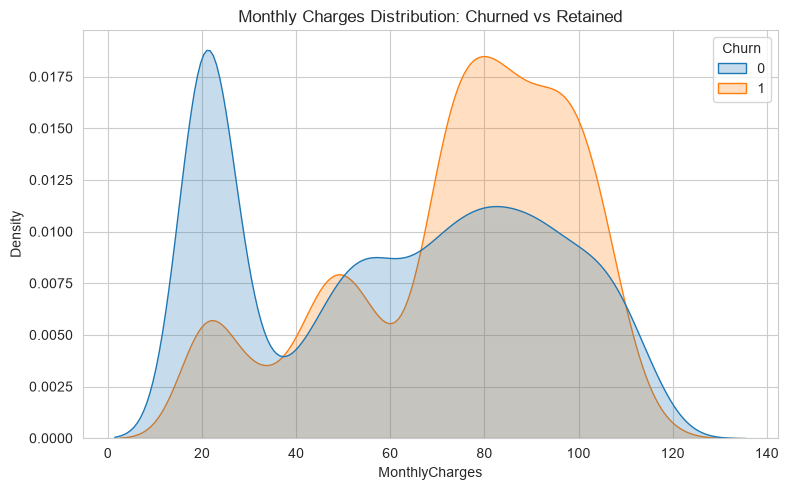

In [9]:
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, common_norm=False)
plt.title("Monthly Charges Distribution: Churned vs Retained")
plt.tight_layout()
plt.show()

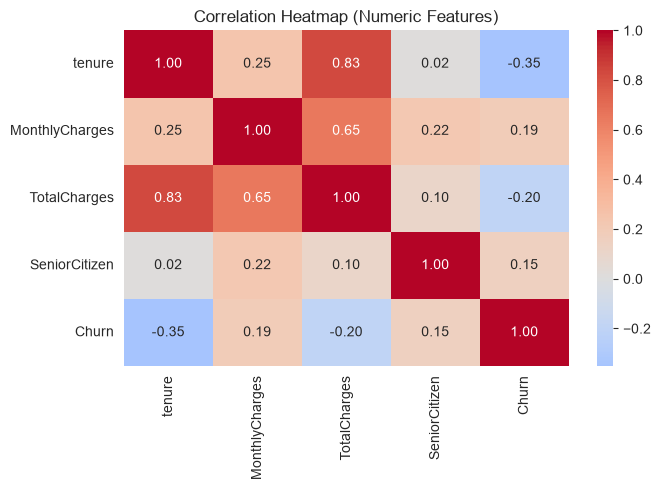

In [10]:
numeric_df = df[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]]

plt.figure(figsize=(7, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

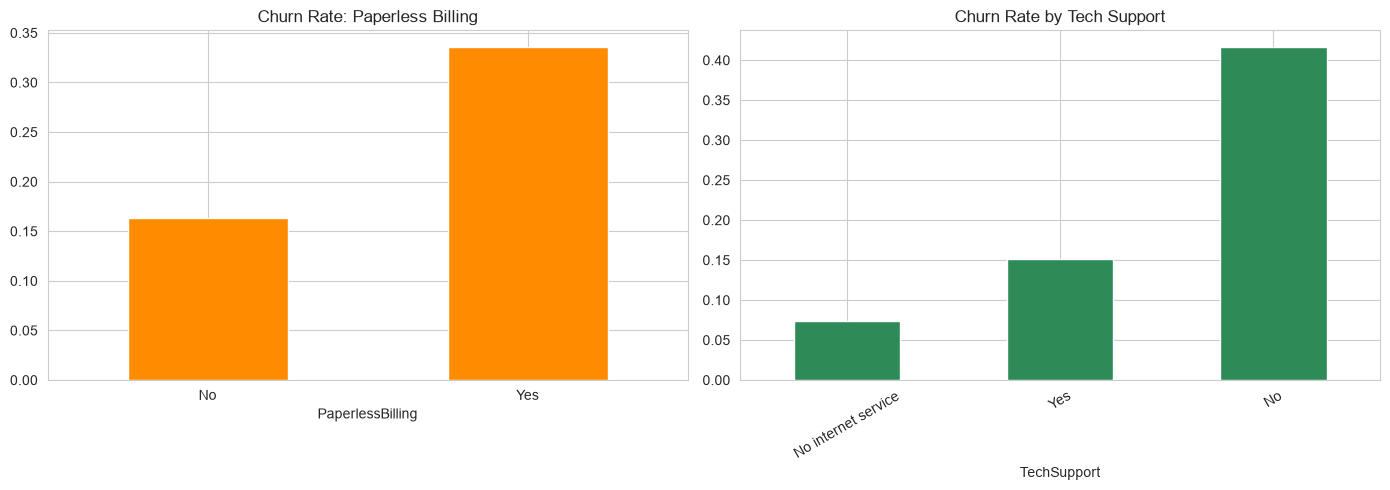

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby("PaperlessBilling")["Churn"].mean().plot(kind="bar", ax=axes[0], color="darkorange")
axes[0].set_title("Churn Rate: Paperless Billing")
axes[0].tick_params(axis="x", rotation=0)

df.groupby("TechSupport")["Churn"].mean().sort_values().plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Churn Rate by Tech Support")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Key EDA Findings

1. **Contract type is the strongest churn driver.** Month-to-month customers churn far more than one-year or two-year contract customers — this is the single biggest lever for retention.
2. **New customers are highest risk.** Churn is heavily concentrated in the 0–12 month tenure bucket; long-tenured customers rarely leave.
3. **Fiber optic internet customers churn more** than DSL or no-internet customers — possibly a pricing or service-quality issue worth flagging.
4. **Electronic check payment method has the highest churn rate** among payment methods — customers not on auto-pay are more likely to leave.
5. **Lack of Tech Support correlates with higher churn** — customers without tech support add-ons churn noticeably more.
6. **Paperless billing customers churn slightly more**, possibly linked to the same segment that's more price-sensitive or less "locked in."
7. **Higher MonthlyCharges correlates with churn** — churned customers cluster at the higher end of the monthly charge distribution.

**Business takeaway:** Retention efforts should prioritize month-to-month, low-tenure customers with fiber internet, no tech support, and electronic-check payment — this segment has compounding risk factors.